<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/part1_sine_wave_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 1: Building and Understanding GANs from Scratch

## Task 1: Reproducing the Sine-Wave GAN

In this section, I reproduce the tutorial's GAN, which learns to generate
2D points (x, y) lying along a noisy sine wave y = sin(x) + noise.

We use a simple vanilla GAN with fully-connected layers for both the
Generator and Discriminator, trained with the standard minimax objective.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Real data sampler

We define a function that draws real samples from the target distribution:
a noisy sine wave over the range [-2π, 2π].

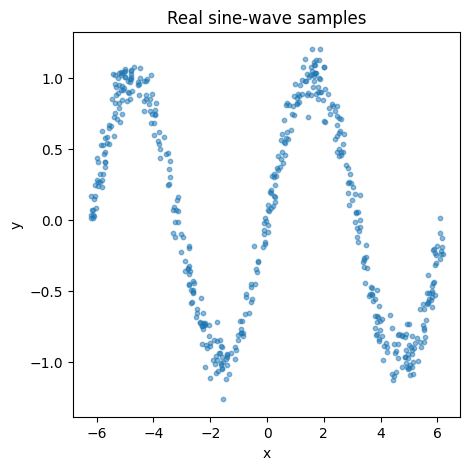

In [2]:
def sample_real_sine_data(n_samples):
    """
    Generate real samples from a noisy sine wave: y = sin(x) + noise.
    Returns a tensor of shape (n_samples, 2) representing (x, y) points.
    """
    x = np.random.uniform(-2 * np.pi, 2 * np.pi, size=n_samples)
    y = np.sin(x) + 0.1 * np.random.randn(n_samples)
    data = np.stack([x, y], axis=1).astype(np.float32)
    return torch.from_numpy(data)

# Quick sanity check
sample = sample_real_sine_data(500).numpy()
plt.figure(figsize=(5, 5))
plt.scatter(sample[:, 0], sample[:, 1], s=10, alpha=0.5)
plt.title("Real sine-wave samples")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Generator and Discriminator networks

- The **Generator** maps random noise `z` to a 2D point `(x, y)`.
- The **Discriminator** takes a 2D point and outputs a logit indicating
  how "real" it believes that point is.

In [3]:
class Generator(nn.Module):
    """
    Takes random noise z and maps it to a 2D point (x, y),
    trying to mimic the real data distribution.
    """
    def __init__(self, noise_dim=2, hidden_dim=32, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    Takes a 2D point and outputs a single logit indicating
    how "real" it thinks the point is (higher = more real).
    """
    def __init__(self, in_dim=2, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

### Training loop

We train the Discriminator and Generator alternately using
`BCEWithLogitsLoss` (a numerically stable combination of sigmoid + binary
cross-entropy). The Discriminator is trained to separate real from fake
samples; the Generator is trained to fool the Discriminator.

In [4]:
def train_gan(generator, discriminator, sample_real_fn, noise_dim=2,
              n_epochs=5000, batch_size=128, lr=2e-4, log_every=500):
    """
    Trains a simple GAN using the standard minimax objective.
    Returns lists of generator/discriminator losses for plotting.
    """
    generator.to(device)
    discriminator.to(device)

    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr)
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr)

    g_losses, d_losses = [], []

    for epoch in range(n_epochs):
        # ---- Train Discriminator ----
        real_data = sample_real_fn(batch_size).to(device)
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_data = generator(z).detach()  # detach: don't backprop into G here

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        d_real_loss = criterion(discriminator(real_data), real_labels)
        d_fake_loss = criterion(discriminator(fake_data), fake_labels)
        d_loss = d_real_loss + d_fake_loss

        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # ---- Train Generator ----
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_data = generator(z)
        g_loss = criterion(discriminator(fake_data), real_labels)

        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    return g_losses, d_losses

### Visualisation helpers

Two helper functions: one to plot real vs. generated samples side by side,
and one to plot the training loss curves.

In [5]:
def plot_real_vs_generated(generator, sample_real_fn, noise_dim=2,
                            n_samples=1000, title="Real vs Generated"):
    """Scatter-plots real samples against generator output for visual comparison."""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, noise_dim, device=device)
        fake_data = generator(z).cpu().numpy()
    real_data = sample_real_fn(n_samples).numpy()
    generator.train()

    plt.figure(figsize=(6, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=10, alpha=0.5, label="Real")
    plt.scatter(fake_data[:, 0], fake_data[:, 1], s=10, alpha=0.5, label="Generated")
    plt.legend()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_losses(g_losses, d_losses, title="Training Losses"):
    """Plots generator and discriminator loss curves over training."""
    plt.figure(figsize=(6, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

### Train the sine-wave GAN and inspect results

Epoch 500/5000 | D loss: 1.1167 | G loss: 0.9722
Epoch 1000/5000 | D loss: 1.0727 | G loss: 1.2509
Epoch 1500/5000 | D loss: 1.0861 | G loss: 0.9978
Epoch 2000/5000 | D loss: 1.3677 | G loss: 0.7610
Epoch 2500/5000 | D loss: 1.3252 | G loss: 0.7178
Epoch 3000/5000 | D loss: 1.3022 | G loss: 0.7320
Epoch 3500/5000 | D loss: 1.2747 | G loss: 0.8281
Epoch 4000/5000 | D loss: 1.2677 | G loss: 0.7653
Epoch 4500/5000 | D loss: 1.3600 | G loss: 0.7434
Epoch 5000/5000 | D loss: 1.3726 | G loss: 0.7153


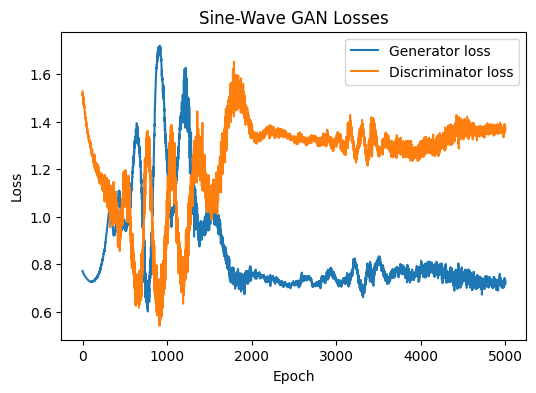

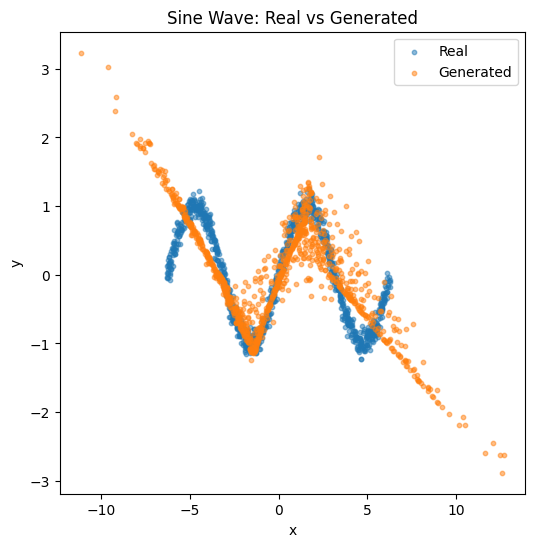

In [6]:
gen_sine = Generator(noise_dim=2, hidden_dim=32, out_dim=2)
disc_sine = Discriminator(in_dim=2, hidden_dim=32)

g_losses_sine, d_losses_sine = train_gan(
    gen_sine, disc_sine, sample_real_sine_data, noise_dim=2, n_epochs=5000
)

plot_losses(g_losses_sine, d_losses_sine, title="Sine-Wave GAN Losses")
plot_real_vs_generated(gen_sine, sample_real_sine_data, title="Sine Wave: Real vs Generated")